In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./datasets/open-f-c.csv")
print(df.head())

    DUT  CMH  CML   freq         Sys11         Sys14
0  open    3    2  10000  2.210000e-13  2.250000e-13
1  open    3    2  11000  2.220000e-13  2.280000e-13
2  open    3    2  12000  2.220000e-13  2.270000e-13
3  open    3    2  13000  2.220000e-13  2.270000e-13
4  open    3    2  14000  2.220000e-13  2.270000e-13


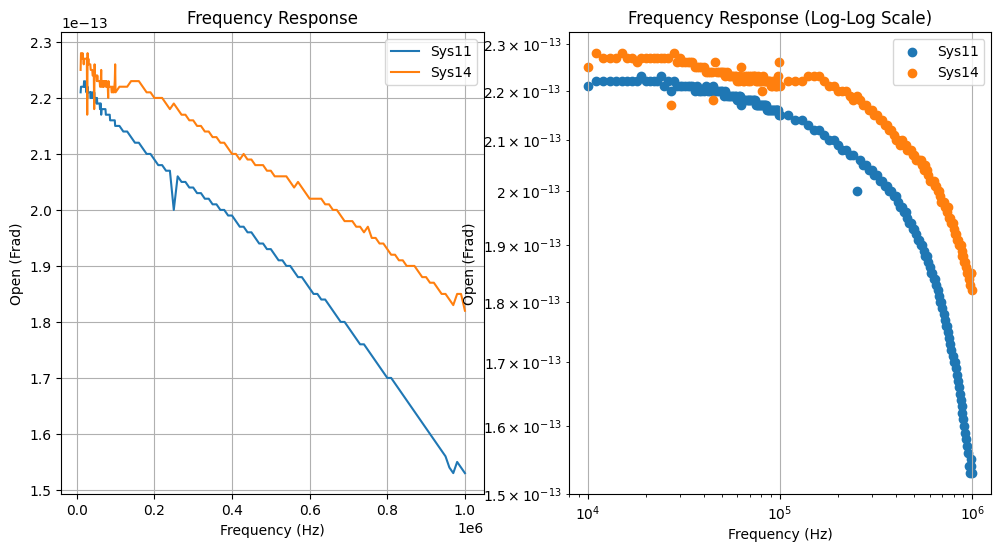

In [ ]:
freq = df['freq'].to_numpy()
sys11 = df['Sys11'].to_numpy()
sys14 = df['Sys14'].to_numpy()

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(12, 6))

axes[0].plot(freq, sys11, label='Sys11')
axes[0].plot(freq, sys14, label='Sys14')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Open (Frad)')
axes[0].set_title('Frequency Dependence')
axes[0].grid()
axes[0].legend()

axes[1].scatter(freq, sys11, label='Sys11')
axes[1].scatter(freq, sys14, label='Sys14')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Open (Frad)')
axes[1].set_title('Frequency Dependence (Log-Log Scale)')
axes[1].grid()
axes[1].legend()
plt.show()



[2.21255180e-13 2.21047179e-13 2.20781411e-13 2.20442035e-13
 2.20008996e-13 2.19456981e-13 2.18754176e-13 2.17860803e-13
 2.16727466e-13 2.15293368e-13 2.13484529e-13 2.11212276e-13
 2.08372403e-13 2.04845651e-13 2.00500365e-13 1.95198407e-13
 1.88805417e-13 1.81206194e-13 1.72324998e-13 1.62148910e-13]


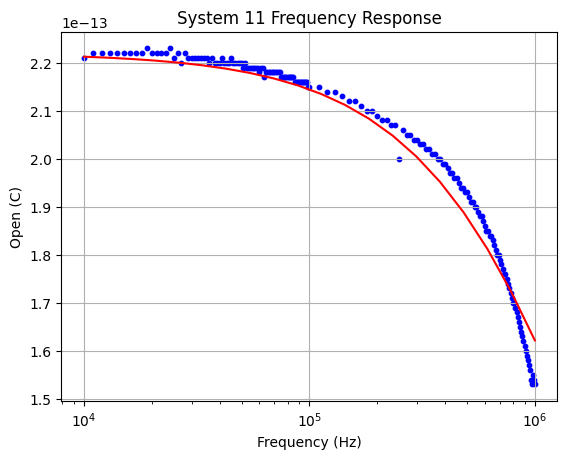

In [ ]:
x_freq = np.logspace(4,6, num=20)
y_c = 2.22e-13 / (1.0 + 2.8e-7*np.power(x_freq, 1.02))

print(y_c)
plt.scatter(freq, sys11, label='Sys11', s=10, color='blue')
plt.plot(x_freq, y_c, label='C', color='red')
plt.xscale('log')
plt.grid()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Open (C)')
plt.title('System 11 Frequency Dependence')
plt.show()

Fitted Normal Distribution Parameters: mu=2.3263115843688797e-28, sigma=1.3600325373315798e-15


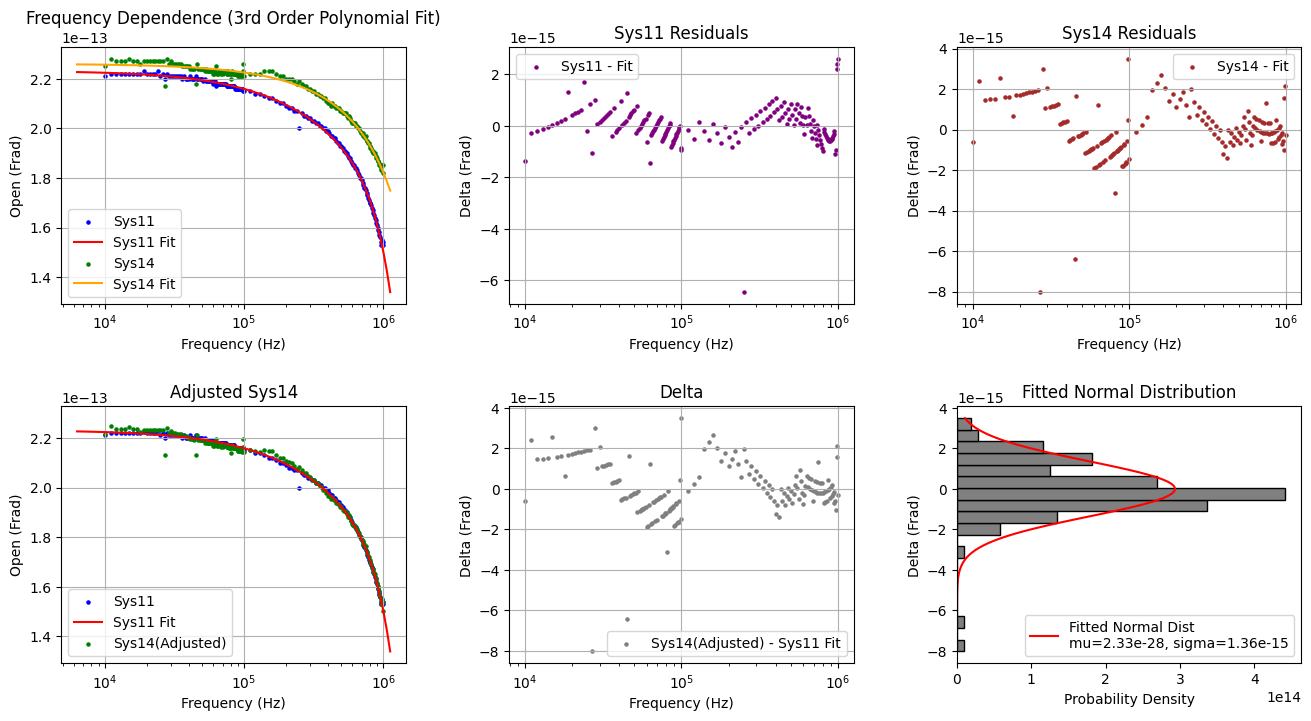

In [329]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(16, 8), )

x_freq = np.logspace(3.8,6.05, num=100)

sys11_coefs = np.polyfit(freq, sys11, 3)
sys11_poly_func = np.poly1d(sys11_coefs)

sys14_coefs = np.polyfit(freq, sys14, 3)
sys14_poly_func = np.poly1d(sys14_coefs)

ax[0][0].scatter(freq, sys11, label='Sys11', s=5, color='blue')
ax[0][0].plot(x_freq, sys11_poly_func(x_freq), label='Sys11 Fit', color='red')

ax[0][0].scatter(freq, sys14, label='Sys14', s=5, color='green')
ax[0][0].plot(x_freq, sys14_poly_func(x_freq), label='Sys14 Fit', color='orange')
ax[0][0].grid()
ax[0][0].set_xlabel('Frequency (Hz)')
ax[0][0].set_ylabel('Open (Frad)')
ax[0][0].set_title('Frequency Dependence (3rd Order Polynomial Fit)')
ax[0][0].set_xscale('log')
#ax[0][0].set_yscale('log')
ax[0][0].legend()

#
# Residuals of sys11 after removing the polynomial fit
#
sys11_diff = sys11 - sys11_poly_func(freq)
ax[0][1].scatter(freq, sys11_diff, label='Sys11 - Fit', color='purple', s=5)
ax[0][1].grid()
ax[0][1].set_xlabel('Frequency (Hz)')
ax[0][1].set_ylabel('Delta (Frad)')
ax[0][1].set_title('Sys11 Residuals')
ax[0][1].set_xscale('log')
ax[0][1].legend()

#
# Residuals of sys14 after removing the polynomial fit
#
sys14_diff = sys14 - sys14_poly_func(freq)
ax[0][2].scatter(freq, sys14_diff, label='Sys14 - Fit', color='brown', s=5)
ax[0][2].grid()
ax[0][2].set_xlabel('Frequency (Hz)')
ax[0][2].set_ylabel('Delta (Frad)')
ax[0][2].set_title('Sys14 Residuals')
ax[0][2].set_xscale('log')
ax[0][2].legend()

#
# Plot adjusted Sys14 by removing the polynomial fit and adding the Sys11 fit
#
sys14_adjusted = sys14 - sys14_poly_func(freq) + sys11_poly_func(freq)

ax[1][0].scatter(freq, sys11, label='Sys11', s=5, color='blue')
ax[1][0].plot(x_freq, sys11_poly_func(x_freq), label='Sys11 Fit', color='red')
ax[1][0].scatter(freq, sys14_adjusted, label='Sys14(Adjusted)', s=5, color='green')

ax[1][0].grid()
ax[1][0].set_xlabel('Frequency (Hz)')
ax[1][0].set_ylabel('Open (Frad)')
ax[1][0].set_title('Adjusted Sys14')
ax[1][0].set_xscale('log')
#ax[1][0].set_yscale('log')
ax[1][0].set_ylim(ax[0][0].get_ylim())  # Match y-axis limits with the first plot
ax[1][0].legend()


#
# Plot the difference between Sys11 Fit and the adjusted Sys14
#
sys14_sys11_diff = sys14_adjusted - sys11_poly_func(freq)

ax[1][1].scatter(freq, sys14_sys11_diff, label='Sys14(Adjusted) - Sys11 Fit', color='gray', s=5)
ax[1][1].grid()
ax[1][1].set_xlabel('Frequency (Hz)')
ax[1][1].set_ylabel('Delta (Frad)')
ax[1][1].set_title('Delta')
ax[1][1].set_xscale('log')
ax[1][1].legend()

params = stats.norm.fit(sys14_sys11_diff)
mu = params[0]
sigma = params[1]

x = np.linspace(min(sys14_sys11_diff), max(sys14_sys11_diff), 100)
estimated_dist = stats.norm.pdf(x, loc=mu, scale=sigma)

print(f"Fitted Normal Distribution Parameters: mu={mu}, sigma={sigma}")

#
# Plot the histogram of the differences and the fitted normal distribution
#

ax[1][2].hist(sys14_sys11_diff, bins=20, color='gray', edgecolor='black', density=True, orientation='horizontal')
ax[1][2].plot(estimated_dist, x, label='Fitted Normal Dist', color='red')
ax[1][2].set_ylabel('Delta (Frad)')
ax[1][2].set_xlabel('Probability Density')
ax[1][2].set_title('Fitted Normal Distribution')
# show mu and sigma in the legend
ax[1][2].legend([f'Fitted Normal Dist\nmu={mu:.2e}, sigma={sigma:.2e}'])

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()